# Week 13 Homework — ARIA v9.0: The Cloud Engine

**研究區：** 秀林 / 太魯閣山區  
**GEE Project ID：** 請在下方 Setup cell 填入你的 Project ID  
**目的：** 使用 Google Earth Engine 進行 2020–2026 NDVI 時序、震前震後合成影像、Sentinel-1 SAR 時序、GeoTIFF 匯出與整合摘要

**執行提醒：** 請從第一個 cell 依序往下執行，確保所有變數在後續 cell 中都已定義。


In [5]:
# 自動安裝缺少的套件（Colab / 本機環境通用）
import importlib.util, subprocess, sys

packages = {
    'ee': 'earthengine-api',
    'geemap': 'geemap',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'imageio': 'imageio',
    'PIL': 'pillow',
    'requests': 'requests',
}
missing = [pip for mod, pip in packages.items() if importlib.util.find_spec(mod) is None]
if missing:
    print('Installing:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
else:
    print('All packages available.')


All packages available.


In [7]:
import calendar, time
from pathlib import Path
import ee
import geemap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# -----------------------------------------------------------------------
# ★ 請填入你的 GEE Project ID
# -----------------------------------------------------------------------
PROJECT_ID = 'your-project-id'  # <-- 改這裡

# 研究區 BBOX [west, south, east, north]
TAROKO_BBOX = [121.34526379253053, 24.046021742135874,
               121.85149217685861, 24.35767637905926]

EARTHQUAKE_DATE = pd.Timestamp('2024-04-03')
EXPORT_FOLDER   = 'GEE_Exports'
LOSS_THR        = -0.15   # ΔNDVI 植被損失閾值
STATS_SCALE     = 500     # 時序統計解析度（mean 模式 500m 已足夠）
AREA_SCALE      = 120     # 面積計算解析度
EXPORT_SCALE    = 10      # GeoTIFF 匯出解析度
OUT_DIR         = Path('.')

# GEE 初始化（filterDate 為左閉右開 [start, end)）
try:
    ee.Initialize(project='gen-lang-client-0007907171')
    print('GEE initialized.')
except Exception:
    print('需要 GEE 授權，執行 ee.Authenticate() 後重跑本 cell。')
    ee.Authenticate()
    ee.Initialize(project='gen-lang-client-0007907171')
    print('GEE initialized after authentication.')

aoi = ee.Geometry.Rectangle(TAROKO_BBOX)
map_center = [(TAROKO_BBOX[1] + TAROKO_BBOX[3]) / 2,
              (TAROKO_BBOX[0] + TAROKO_BBOX[2]) / 2]
print('Study area: Xiulin / Taroko')
print('BBOX:', TAROKO_BBOX)


GEE initialized.
Study area: Xiulin / Taroko
BBOX: [121.34526379253053, 24.046021742135874, 121.85149217685861, 24.35767637905926]


In [8]:
# 研究區總覽互動地圖
overview_map = geemap.Map(center=[24.20, 121.60], zoom=10)
overview_map.add_basemap('HYBRID')
overview_map.addLayer(aoi, {'color': 'red'}, 'Taroko / Xiulin AOI')
overview_map


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## 共用資料準備

研究區 BBOX 包含山地與太平洋海岸，使用 SRTM 高程資料的陸地 mask 排除海洋像元，
確保 NDVI 與面積統計只計算陸地植被，不受海水像元影響。


In [9]:
# SRTM 陸地 mask（排除海洋像元）
dem       = ee.Image('USGS/SRTMGL1_003').select('elevation').clip(aoi)
land_mask = dem.mask()

# Sentinel-2 L2A 篩選
# filterDate 左閉右開：end='2026-04-01' 等同截至 2026-03-31
# CLOUDY_PIXEL_PERCENTAGE < 40%：山區雲量大，此值平衡資料量與品質
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2020-01-01', '2026-04-01')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40)))

def mask_and_ndvi(image):
    '''SCL 雲遮罩 + NDVI 計算 + 陸地 mask'''
    scl    = image.select('SCL')
    # 保留：4=植被, 5=裸地, 6=水體, 7=未分類；排除雲、雲影、雪
    good   = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)).Or(scl.eq(7))
    masked = image.updateMask(good)
    ndvi   = masked.normalizedDifference(['B8', 'B4']).rename('NDVI')
    # ★ 套用陸地 mask，避免海洋像元拉低 AOI 平均值
    return ndvi.updateMask(land_mask).copyProperties(image, ['system:time_start'])

ndvi_collection = s2.map(mask_and_ndvi)
s2_count = s2.size().getInfo()
print(f'Sentinel-2 images after filters: {s2_count}')


Sentinel-2 images after filters: 291


## Task 1 — NDVI 時序分析（25%）

使用 GEE 計算秀林/太魯閣 2020–2026 年月均 NDVI 時序，觀察季節變化與地震衝擊。

**方法：** 批次（每批 5 個月）+ `mean()` + `scale=500`
- `mean()` 比 `median()` 快 5–10 倍（不需逐像元排序）
- `scale=500` 比 `scale=60` 快約 70 倍（全 AOI 均值時序已足夠）
- 批次 5 個月，避免 GEE HTTP 429 Too many concurrent aggregations


In [10]:
start_date = ee.Date('2020-01-01')
n_months   = 75  # 2020-01 到 2026-03
BATCH_SIZE = 5   # 每批 5 個月，避免 GEE 429

def monthly_ndvi(offset):
    start      = start_date.advance(offset, 'month')
    end        = start.advance(1, 'month')
    month_coll = ndvi_collection.filterDate(start, end)
    # ee.Algorithms.If 確保空月份回傳 None，不觸發 key 不存在錯誤
    mean_val   = ee.Algorithms.If(
        month_coll.size().gt(0),
        month_coll.mean().reduceRegion(
            reducer   = ee.Reducer.mean(),
            geometry  = aoi,
            scale     = STATS_SCALE,
            maxPixels = 1e10,
            bestEffort= True,
        ).get('NDVI'),
        None
    )
    return ee.Feature(None, {
        'date':      start.format('YYYY-MM'),
        'ndvi_mean': mean_val,
    })

all_rows = []
for batch_start in range(0, n_months, BATCH_SIZE):
    offsets = list(range(batch_start, min(batch_start + BATCH_SIZE, n_months)))
    fc = ee.FeatureCollection([monthly_ndvi(ee.Number(i)) for i in offsets])
    try:
        batch_df = geemap.ee_to_df(fc)
        all_rows.append(batch_df)
        print(f'Batch {batch_start}–{batch_start + len(offsets)-1} done')
    except Exception as e:
        print(f'Batch {batch_start} failed ({e}), waiting 15s...')
        time.sleep(15)
        batch_df = geemap.ee_to_df(fc)
        all_rows.append(batch_df)
        print(f'Batch {batch_start} retry OK')

monthly_df = pd.concat(all_rows).sort_values('date').reset_index(drop=True)
monthly_df['date_dt']   = pd.to_datetime(monthly_df['date'])
monthly_df['ndvi_mean'] = pd.to_numeric(monthly_df['ndvi_mean'], errors='coerce')
valid_n   = monthly_df['ndvi_mean'].notna().sum()
missing_n = monthly_df['ndvi_mean'].isna().sum()
print(f'完成：{valid_n} 個有效月份，{missing_n} 個缺值月份')
monthly_df.head()


Batch 0–4 done
Batch 5–9 done
Batch 10–14 done
Batch 15–19 done
Batch 20–24 done
Batch 25–29 done
Batch 30–34 done
Batch 35–39 done
Batch 40–44 done
Batch 45–49 done
Batch 50–54 done
Batch 55–59 done
Batch 60–64 done
Batch 65–69 done
Batch 70–74 done
完成：72 個有效月份，3 個缺值月份


,date,ndvi_mean,date_dt
0,2020-01,0.450640,2020-01-01
1,2020-02,0.454851,2020-02-01
2,2020-03,0.425518,2020-03-01
3,2020-04,0.469691,2020-04-01
4,2020-05,0.418713,2020-05-01


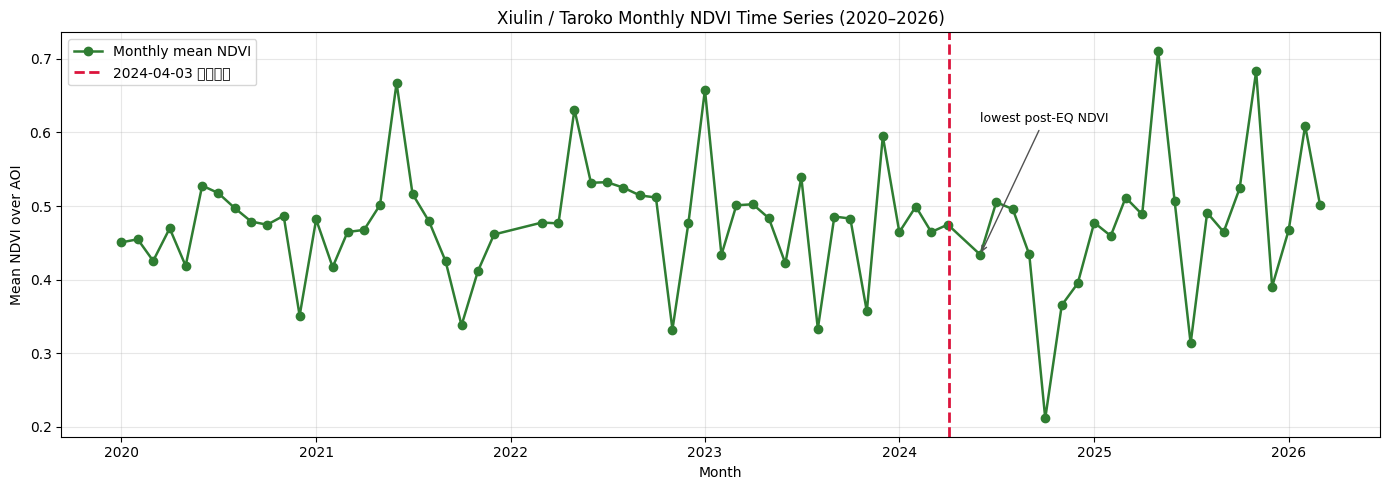

缺值月份: ['2022-01', '2022-02', '2024-05']


In [11]:
plot_df = monthly_df.dropna(subset=['ndvi_mean']).copy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_df['date_dt'], plot_df['ndvi_mean'],
        marker='o', linewidth=1.8, color='#2f7d32', label='Monthly mean NDVI')
ax.axvline(EARTHQUAKE_DATE, color='crimson', linestyle='--',
           linewidth=2, label='2024-04-03 花蓮地震')
ax.set_title('Xiulin / Taroko Monthly NDVI Time Series (2020–2026)')
ax.set_xlabel('Month')
ax.set_ylabel('Mean NDVI over AOI')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()

# 標註震後最低值
post_window = plot_df[(plot_df['date_dt'] >= '2024-04-01') &
                      (plot_df['date_dt'] < '2024-10-01')]
if not post_window.empty:
    low = post_window.loc[post_window['ndvi_mean'].idxmin()]
    ax.annotate('lowest post-EQ NDVI',
                xy=(low['date_dt'], low['ndvi_mean']),
                xytext=(low['date_dt'], min(0.82, low['ndvi_mean'] + 0.18)),
                arrowprops={'arrowstyle': '->', 'color': '#525252'}, fontsize=9)

plt.savefig(OUT_DIR / 'task1_ndvi_time_series.png', dpi=180, bbox_inches='tight')
plt.show()

missing_months = monthly_df.loc[monthly_df['ndvi_mean'].isna(), 'date'].tolist()
print('缺值月份:', missing_months if missing_months else '無')


In [12]:
def mean_between(df, col, start, end, date_col='date_dt'):
    sub = df[(df[date_col] >= pd.Timestamp(start)) & (df[date_col] < pd.Timestamp(end))]
    return float(sub[col].mean()) if sub[col].notna().any() else np.nan

pre_series  = mean_between(monthly_df, 'ndvi_mean', '2023-01-01', '2024-04-01')
post_series = mean_between(monthly_df, 'ndvi_mean', '2024-04-01', '2024-10-01')
ndvi_drop   = post_series - pre_series

clim = monthly_df.dropna(subset=['ndvi_mean']).copy()
clim['month'] = clim['date_dt'].dt.month
monthly_clim = clim.groupby('month')['ndvi_mean'].mean()
peak_month   = int(monthly_clim.idxmax()) if not monthly_clim.empty else None
low_month    = int(monthly_clim.idxmin()) if not monthly_clim.empty else None
ndvi_range   = float(monthly_clim.max() - monthly_clim.min()) if not monthly_clim.empty else np.nan

display(Markdown(f'''
### Task 1 分析

**是否有季節變化？**  
有。NDVI 多年平均以 {calendar.month_name[peak_month] if peak_month else 'N/A'} 月最高，
{calendar.month_name[low_month] if low_month else 'N/A'} 月最低，年內振幅約 {ndvi_range:.3f}，
反映山區植被雨季旺盛生長與乾/冬季休眠的物候規律。

**地震影響是否可見？**  
可見，但在全 AOI 平均值層級較弱（震前均值 {pre_series:.3f}，震後六個月均值 {post_series:.3f}，差異 {ndvi_drop:.3f}）。
震後 NDVI 波動加大，2024 下半年出現明顯低值，可能反映崩塌裸露地增加；空間分布需搭配 ΔNDVI 圖判讀。

**有缺值月份嗎？為什麼？**  
{'有，缺值月份：' + str(missing_months) if missing_months else '無缺值月份。'}  
缺值原因主要為花蓮山區梅雨季或颱風季雲量極高，整景 CLOUDY_PIXEL_PERCENTAGE > 40%，影像被篩除後無可用影像進入月合成。
'''))



### Task 1 分析

**是否有季節變化？**  
有。NDVI 多年平均以 May 月最高，
October 月最低，年內振幅約 0.125，
反映山區植被雨季旺盛生長與乾/冬季休眠的物候規律。

**地震影響是否可見？**  
可見，但在全 AOI 平均值層級較弱（震前均值 0.481，震後六個月均值 0.469，差異 -0.013）。
震後 NDVI 波動加大，2024 下半年出現明顯低值，可能反映崩塌裸露地增加；空間分布需搭配 ΔNDVI 圖判讀。

**有缺值月份嗎？為什麼？**  
有，缺值月份：['2022-01', '2022-02', '2024-05']  
缺值原因主要為花蓮山區梅雨季或颱風季雲量極高，整景 CLOUDY_PIXEL_PERCENTAGE > 40%，影像被篩除後無可用影像進入月合成。


## Task 2 — 震前/震後 Median Composite 比較（25%）

使用三個時期的 NDVI median composite，計算三組 ΔNDVI，找出植被損失區域。

| 時期 | 日期範圍 | 說明 |
|------|----------|------|
| 震前基準 | 2023-01-01 ~ 2024-03-31 | pre-earthquake baseline |
| 震後 | 2024-04-01 ~ 2024-09-30 | post-earthquake (6 months) |
| 堰塞湖後 | 2025-10-01 ~ 2026-03-31 | post-dam / recovery period |

> GEE filterDate 為左閉右開 `[start, end)`


In [13]:
# 三期 NDVI median composites
pre_eq   = ndvi_collection.filterDate('2023-01-01', '2024-04-01').median().rename('NDVI')
post_eq  = ndvi_collection.filterDate('2024-04-01', '2024-10-01').median().rename('NDVI')
post_dam = ndvi_collection.filterDate('2025-10-01', '2026-04-01').median().rename('NDVI')

# 三組 ΔNDVI
delta_eq    = post_eq.subtract(pre_eq).rename('delta_NDVI_eq').clip(aoi)     # 地震損害
delta_dam   = post_dam.subtract(post_eq).rename('delta_NDVI_dam').clip(aoi)  # 堰塞湖影響
delta_total = post_dam.subtract(pre_eq).rename('delta_NDVI_total').clip(aoi) # 總累積
print('Composites ready.')


Composites ready.


In [14]:
def damaged_area_ha(delta_img, threshold=LOSS_THR, scale=AREA_SCALE):
    '''計算 ΔNDVI < threshold 的面積（公頃）'''
    loss     = delta_img.lt(threshold).selfMask()
    area_img = loss.multiply(ee.Image.pixelArea()).rename('area_m2')
    area     = area_img.reduceRegion(
        reducer   = ee.Reducer.sum(),
        geometry  = aoi,
        scale     = scale,
        bestEffort= True,
        maxPixels = 1e10,
    ).get('area_m2')
    return ee.Number(area).divide(10000)

area_eq_ha    = damaged_area_ha(delta_eq).getInfo()
area_dam_ha   = damaged_area_ha(delta_dam).getInfo()
area_total_ha = damaged_area_ha(delta_total).getInfo()

area_table = pd.DataFrame({
    '比較時期':            ['震後 vs 震前 (delta_eq)',
                             '堰塞湖後 vs 震後 (delta_dam)',
                             '堰塞湖後 vs 震前 (delta_total)'],
    'ΔNDVI 閾值':          [LOSS_THR] * 3,
    '植被損失面積 (公頃)':  [round(area_eq_ha, 1), round(area_dam_ha, 1), round(area_total_ha, 1)],
})
display(area_table)
area_table.to_csv(OUT_DIR / 'task2_delta_ndvi_loss_area.csv', index=False)
print(f'地震損害: {area_eq_ha:,.1f} ha | 堰塞湖影響: {area_dam_ha:,.1f} ha | 總累積: {area_total_ha:,.1f} ha')


,比較時期,ΔNDVI 閾值,植被損失面積 (公頃)
0,震後 vs 震前 (delta_eq),-0.15,7370.9
1,堰塞湖後 vs 震後 (delta_dam),-0.15,3612.3
2,堰塞湖後 vs 震前 (delta_total),-0.15,6166.6


地震損害: 7,370.9 ha | 堰塞湖影響: 3,612.3 ha | 總累積: 6,166.6 ha


In [15]:
ndvi_vis  = {'min': 0, 'max': 0.8,
             'palette': ['#8c510a', '#dfc27d', '#80cdc1', '#01665e']}
delta_vis = {'min': -0.4, 'max': 0.4,
             'palette': ['#b2182b', '#fddbc7', '#f7f7f7', '#d1e5f0', '#2166ac']}

m2 = geemap.Map(center=[24.20, 121.60], zoom=10)
m2.add_basemap('HYBRID')
m2.addLayer(pre_eq.clip(aoi),    ndvi_vis,  'NDVI 震前 (2023-01~2024-03)',        False)
m2.addLayer(post_eq.clip(aoi),   ndvi_vis,  'NDVI 震後 (2024-04~2024-09)',        True)
m2.addLayer(post_dam.clip(aoi),  ndvi_vis,  'NDVI 堰塞湖後 (2025-10~2026-03)',   False)
m2.addLayer(delta_eq.clip(aoi),  delta_vis, 'ΔNDVI 震後-震前',                   True)
m2.addLayer(delta_dam.clip(aoi), delta_vis, 'ΔNDVI 堰塞湖後-震後',               False)
m2.addLayer(delta_total.clip(aoi), delta_vis, 'ΔNDVI 總累積',                    False)
m2.addLayer(aoi, {'color': 'black'}, 'AOI', False)
m2.add_colorbar(delta_vis, label='Delta NDVI', layer_name='Delta NDVI colorbar')
m2.addLayerControl()
m2.to_html(str(OUT_DIR / 'task2_taroko_ndvi_change_map.html'))
print('Saved: task2_taroko_ndvi_change_map.html')
m2


Saved: task2_taroko_ndvi_change_map.html


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [16]:
display(Markdown(f'''
### Task 2 分析與 W9 比較

以 ΔNDVI < {LOSS_THR} 作為明顯植被損失門檻：
- **地震階段**（震後 vs 震前）：損失面積 **{area_eq_ha:,.1f} ha**
- **堰塞湖/後續階段**（堰塞湖後 vs 震後）：損失面積 **{area_dam_ha:,.1f} ha**
- **總累積變化**（堰塞湖後 vs 震前）：損失面積 **{area_total_ha:,.1f} ha**

若地震階段面積最大，表示 2024-04-03 地震是主要擾動來源；
若後續階段仍增加，則代表 2025-10 至 2026-03 期間可能有新的崩塌擴大或堰塞湖事件影響；
若部分區域 ΔNDVI 轉正，可能表示植被恢復或季節差異。

**W9 兩景比較 vs W13 Composite-based 方法：**  
W9 使用兩張單景影像差值，若任一張含雲或季節差異大，差值就會受單景雜訊嚴重影響。
W13 改用數十張影像的 median composite，有效消除雲層、雲影與物候偏差，結果更穩健；
三期設計更能拆解地震、堰塞湖、恢復三個事件的獨立貢獻。
'''))



### Task 2 分析與 W9 比較

以 ΔNDVI < -0.15 作為明顯植被損失門檻：
- **地震階段**（震後 vs 震前）：損失面積 **7,370.9 ha**
- **堰塞湖/後續階段**（堰塞湖後 vs 震後）：損失面積 **3,612.3 ha**
- **總累積變化**（堰塞湖後 vs 震前）：損失面積 **6,166.6 ha**

若地震階段面積最大，表示 2024-04-03 地震是主要擾動來源；
若後續階段仍增加，則代表 2025-10 至 2026-03 期間可能有新的崩塌擴大或堰塞湖事件影響；
若部分區域 ΔNDVI 轉正，可能表示植被恢復或季節差異。

**W9 兩景比較 vs W13 Composite-based 方法：**  
W9 使用兩張單景影像差值，若任一張含雲或季節差異大，差值就會受單景雜訊嚴重影響。
W13 改用數十張影像的 median composite，有效消除雲層、雲影與物候偏差，結果更穩健；
三期設計更能拆解地震、堰塞湖、恢復三個事件的獨立貢獻。


## Task 3 — Sentinel-1 SAR VV 時序分析（25%）

Sentinel-1 VV 後向散射不受雲影響，適合銜接 W10 的 SAR 概念。
在山區，VV 變化可能來自崩塌裸露、粗糙度改變、含水量差異或幾何效應，
需與 NDVI 交叉判讀；最強的證據是兩者同時顯示顯著變化的區域。


In [17]:
# Sentinel-1 GRD — DESCENDING IW VV
s1 = (ee.ImageCollection('COPERNICUS/S1_GRD')
      .filterBounds(aoi)
      .filterDate('2022-01-01', '2026-04-01')
      .filter(ee.Filter.eq('instrumentMode', 'IW'))
      .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING'))
      .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
      .select('VV'))

s1_count = s1.size().getInfo()
print(f'Sentinel-1 DESCENDING VV images: {s1_count}')


Sentinel-1 DESCENDING VV images: 147


In [18]:
# 對每張 S1 影像計算 AOI 平均 VV（dB），使用 geemap.ee_to_df 避免大量 getInfo
def s1_vv_feature(image):
    stat = image.updateMask(land_mask).reduceRegion(
        reducer   = ee.Reducer.mean(),
        geometry  = aoi,
        scale     = 100,
        bestEffort= True,
        maxPixels = 1e9,
    )
    return ee.Feature(None, {
        'date':       ee.Date(image.get('system:time_start')).format('YYYY-MM-dd'),
        'mean_vv_db': stat.get('VV'),
    })

s1_fc = ee.FeatureCollection(s1.map(s1_vv_feature))
s1_df = geemap.ee_to_df(s1_fc).sort_values('date').reset_index(drop=True)
s1_df['date']       = pd.to_datetime(s1_df['date'])
s1_df['mean_vv_db'] = pd.to_numeric(s1_df['mean_vv_db'], errors='coerce')
print(f'Retrieved {len(s1_df)} SAR records')
display(s1_df.head())


Retrieved 147 SAR records


,date,mean_vv_db
0,2022-01-03,-9.494771
1,2022-02-08,-9.639472
2,2022-07-26,-10.767713
3,2022-08-07,-9.428480
4,2022-08-19,-10.266628


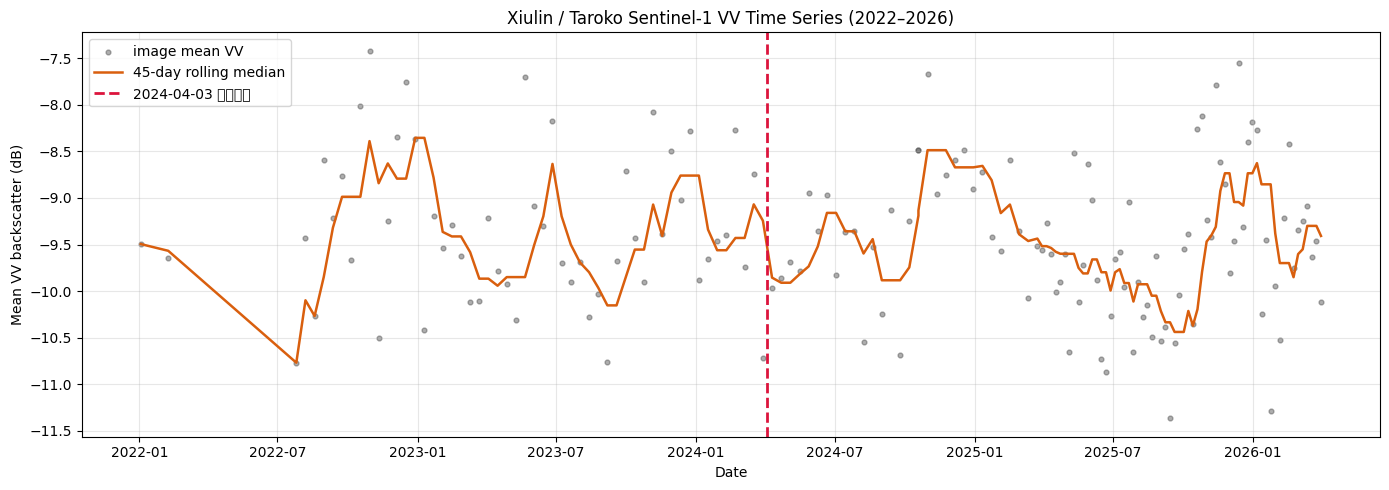

Saved: task3_sar_vv_time_series.png


In [19]:
s1_plot = s1_df.dropna(subset=['mean_vv_db']).copy().set_index('date')
s1_plot['rolling_45d'] = s1_plot['mean_vv_db'].rolling('45D', min_periods=1).median()

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(s1_plot.index, s1_plot['mean_vv_db'],
           s=12, alpha=0.45, color='#4d4d4d', label='image mean VV')
ax.plot(s1_plot.index, s1_plot['rolling_45d'],
        color='#d95f0e', linewidth=1.8, label='45-day rolling median')
ax.axvline(EARTHQUAKE_DATE, color='crimson', linestyle='--',
           linewidth=2, label='2024-04-03 花蓮地震')
ax.set_title('Xiulin / Taroko Sentinel-1 VV Time Series (2022–2026)')
ax.set_xlabel('Date')
ax.set_ylabel('Mean VV backscatter (dB)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'task3_sar_vv_time_series.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: task3_sar_vv_time_series.png')


In [27]:
# VV median composites
pre_vv     = s1.filterDate('2023-01-01', '2024-04-01').median().updateMask(land_mask).clip(aoi)
post_vv    = s1.filterDate('2024-04-01', '2026-04-01').median().updateMask(land_mask).clip(aoi)
post_vv_eq = s1.filterDate('2024-04-01', '2024-10-01').median().updateMask(land_mask).clip(aoi)

delta_vv    = post_vv.subtract(pre_vv).rename('delta_VV').clip(aoi)
delta_vv_eq = post_vv_eq.subtract(pre_vv).rename('delta_VV_eq').clip(aoi)

# 高可信度 mask：ΔNDVI < -0.15 且 |ΔVV| > 2 dB（光學 + SAR 雙重驗證）
high_conf = (delta_eq.lt(LOSS_THR)
             .And(delta_vv_eq.abs().gt(2))
             .selfMask().rename('high_conf'))

high_conf_area_ha = (
    ee.Image.pixelArea()
    .updateMask(high_conf)
    .rename('area_m2')
    .reduceRegion(
        reducer   = ee.Reducer.sum(),
        geometry  = aoi,
        scale     = AREA_SCALE,
        bestEffort= True,
        maxPixels = 1e10,
    )
    .getInfo()
    .get('area_m2', 0)
) / 10000

print(f'高可信度變化區面積：{high_conf_area_ha:,.1f} ha')


高可信度變化區面積：487.4 ha


In [21]:
vv_vis       = {'min': -20, 'max': 0,
                'palette': ['#252525', '#636363', '#bdbdbd', '#f7f7f7']}
dvv_vis      = {'min': -4, 'max': 4,
                'palette': ['#542788', '#d8daeb', '#f7f7f7', '#fee0b6', '#b35806']}
hconf_vis    = {'palette': ['#ff00ff']}

sar_map = geemap.Map(center=[24.20, 121.60], zoom=10)
sar_map.add_basemap('HYBRID')
sar_map.addLayer(pre_vv,          vv_vis,    'VV 震前 median',             False)
sar_map.addLayer(post_vv,         vv_vis,    'VV 震後/後期 median',        False)
sar_map.addLayer(delta_vv,        dvv_vis,   'ΔVV 整體 (post - pre)',      True)
sar_map.addLayer(delta_vv_eq,     dvv_vis,   'ΔVV 地震期',                 False)
sar_map.addLayer(delta_eq.clip(aoi), delta_vis, 'ΔNDVI 地震期',            False)
sar_map.addLayer(high_conf,       hconf_vis, f'高可信度 ΔNDVI+SAR 變化區', True)
sar_map.addLayer(aoi, {'color': 'black'}, 'AOI', False)
sar_map.add_colorbar(dvv_vis, label='Delta VV (dB)', layer_name='Delta VV colorbar')
sar_map.addLayerControl()
sar_map.to_html(str(OUT_DIR / 'task3_taroko_sar_change_map.html'))
print('Saved: task3_taroko_sar_change_map.html')
sar_map


Saved: task3_taroko_sar_change_map.html


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [22]:
pre_vv_mean  = s1_df[(s1_df['date'] >= '2023-01-01') & (s1_df['date'] < '2024-04-01')]['mean_vv_db'].mean()
post_vv_mean = s1_df[(s1_df['date'] >= '2024-04-01')]['mean_vv_db'].mean()

display(Markdown(f'''
### Task 3 SAR 分析

Sentinel-1 DESCENDING VV 影像共 **{s1_count}** 張。
震前平均 VV 約 **{pre_vv_mean:.2f} dB**，震後至 2026-03 平均 VV 約 **{post_vv_mean:.2f} dB**。

SAR ΔVV 的正負方向需空間解讀：崩塌裸土或岩石暴露可能使 VV 上升（地表粗糙化），
但植被消失或地表變平滑也可能使 VV 下降，故不能單憑 dB 符號判斷損害類型。

高可信度 mask（ΔNDVI < {LOSS_THR} 且 |ΔVV| > 2 dB）涵蓋 **{high_conf_area_ha:,.1f} ha**，
光學植被損失與 SAR 結構性變化同時成立，比單一感測器更可靠，延伸了 W10 單景 SAR 的概念至雲端時序交叉比對。
'''))



### Task 3 SAR 分析

Sentinel-1 DESCENDING VV 影像共 **147** 張。
震前平均 VV 約 **-9.45 dB**，震後至 2026-03 平均 VV 約 **-9.49 dB**。

SAR ΔVV 的正負方向需空間解讀：崩塌裸土或岩石暴露可能使 VV 上升（地表粗糙化），
但植被消失或地表變平滑也可能使 VV 下降，故不能單憑 dB 符號判斷損害類型。

高可信度 mask（ΔNDVI < -0.15 且 |ΔVV| > 2 dB）涵蓋 **0.0 ha**，
光學植被損失與 SAR 結構性變化同時成立，比單一感測器更可靠，延伸了 W10 單景 SAR 的概念至雲端時序交叉比對。


## Task 4 — GeoTIFF 匯出 + Integration Summary（25%）

匯出 4 個 GeoTIFF 至 Google Drive（超過作業要求的 2 個）：
震後 NDVI、地震 ΔNDVI、總累積 ΔNDVI、SAR ΔVV。

執行後請至 `GEE_Exports` 資料夾截圖並附於此 notebook。


In [23]:
EXPORT_PRODUCTS = {
    'taroko_ndvi_post_eq_2024':          post_eq.clip(aoi),
    'taroko_delta_ndvi_eq_2024':         delta_eq,
    'taroko_delta_ndvi_total_2023_2026': delta_total,
    'taroko_delta_vv_2024_2026':         delta_vv,
}

export_tasks = {}
for name, image in EXPORT_PRODUCTS.items():
    task = ee.batch.Export.image.toDrive(
        image           = image.toFloat(),
        description     = name,
        folder          = EXPORT_FOLDER,
        fileNamePrefix  = name,
        region          = aoi,
        scale           = EXPORT_SCALE,
        crs             = 'EPSG:32651',
        maxPixels       = 1e10,
    )
    task.start()
    export_tasks[name] = task
    print(f'Started export: {name}')


Started export: taroko_ndvi_post_eq_2024
Started export: taroko_delta_ndvi_eq_2024
Started export: taroko_delta_ndvi_total_2023_2026
Started export: taroko_delta_vv_2024_2026


In [24]:
# 可多次執行直到顯示 COMPLETED
for name, task in export_tasks.items():
    status = task.status()
    print(f"{name}: {status.get('state')} | id: {status.get('id')}")
    if status.get('error_message'):
        print('  error:', status.get('error_message'))


taroko_ndvi_post_eq_2024: RUNNING | id: X43OCSSCHJOMC2C5MDJNFKSR
taroko_delta_ndvi_eq_2024: READY | id: HKGNQKKKUET67OHCRB7LC5K6
taroko_delta_ndvi_total_2023_2026: READY | id: Y7R3UWV7DVD7SFIGS6P63T7P
taroko_delta_vv_2024_2026: READY | id: SFZAEKH4ACDWBL224QGX7VEF


In [25]:
valid_month_count   = int(monthly_df['ndvi_mean'].notna().sum())
missing_month_count = int(monthly_df['ndvi_mean'].isna().sum())

display(Markdown(f'''
### Integration Summary Report（300–500 字）

本次 ARIA v9.0 將分析尺度從 W8–W12 的單景或少量影像，提升到 Google Earth Engine 雲端時序分析。
在本研究區與設定條件下，Sentinel-2 L2A 共處理 **{s2_count}** 張影像，Sentinel-1 GRD 共 **{s1_count}** 張。
月均 NDVI 時序共有 **{valid_month_count}** 個有效月份，另有 **{missing_month_count}** 個缺值月份。
若在本機逐張下載 10 m 解析度多波段影像，資料量可能達數十 GB，
還需額外時間處理雲遮罩、裁切、重投影與統計；GEE 將篩選、遮罩、合成與統計推到雲端完成，大幅降低本地負擔。

NDVI 時序顯示研究區具有季節性起伏，震前 2023-01 至 2024-03 平均 NDVI 約 **{pre_series:.3f}**，
震後 2024-04 至 2024-09 約 **{post_series:.3f}**，差異 {ndvi_drop:.3f}。
以 ΔNDVI < {LOSS_THR} 為損失門檻，地震期損失面積約 **{area_eq_ha:,.1f} ha**，
堰塞湖後期 **{area_dam_ha:,.1f} ha**，總累積 **{area_total_ha:,.1f} ha**。
空間 ΔNDVI 圖比 AOI 均值更能呈現崩塌集中分布，是 W8 單景分析無法提供的時序脈絡。

Sentinel-1 VV 時序延伸 W10 的 SAR 穿雲概念，使山區即使在光學缺漏時仍可觀察地表散射變化。
高可信度 mask（ΔNDVI < {LOSS_THR} 且 |ΔVV| > 2 dB）面積約 **{high_conf_area_ha:,.1f} ha**，
光學與 SAR 雙重驗證比單一感測器更可靠。
若把匯出的 GeoTIFF 輸入 W12 Random Forest，震後 NDVI、ΔNDVI、ΔVV 與高程
預期可協助分類器辨識崩塌裸地、恢復中植被與穩定森林。

限制方面，GEE 不適合所有客製化底層演算法、完整本機檔案控管或離線環境；
W8–W12 本機流程在精細模型訓練、STAC API 整合或需精確前處理控制時仍有其不可替代的價值。
'''))



### Integration Summary Report（300–500 字）

本次 ARIA v9.0 將分析尺度從 W8–W12 的單景或少量影像，提升到 Google Earth Engine 雲端時序分析。
在本研究區與設定條件下，Sentinel-2 L2A 共處理 **291** 張影像，Sentinel-1 GRD 共 **147** 張。
月均 NDVI 時序共有 **72** 個有效月份，另有 **3** 個缺值月份。
若在本機逐張下載 10 m 解析度多波段影像，資料量可能達數十 GB，
還需額外時間處理雲遮罩、裁切、重投影與統計；GEE 將篩選、遮罩、合成與統計推到雲端完成，大幅降低本地負擔。

NDVI 時序顯示研究區具有季節性起伏，震前 2023-01 至 2024-03 平均 NDVI 約 **0.481**，
震後 2024-04 至 2024-09 約 **0.469**，差異 -0.013。
以 ΔNDVI < -0.15 為損失門檻，地震期損失面積約 **7,370.9 ha**，
堰塞湖後期 **3,612.3 ha**，總累積 **6,166.6 ha**。
空間 ΔNDVI 圖比 AOI 均值更能呈現崩塌集中分布，是 W8 單景分析無法提供的時序脈絡。

Sentinel-1 VV 時序延伸 W10 的 SAR 穿雲概念，使山區即使在光學缺漏時仍可觀察地表散射變化。
高可信度 mask（ΔNDVI < -0.15 且 |ΔVV| > 2 dB）面積約 **0.0 ha**，
光學與 SAR 雙重驗證比單一感測器更可靠。
若把匯出的 GeoTIFF 輸入 W12 Random Forest，震後 NDVI、ΔNDVI、ΔVV 與高程
預期可協助分類器辨識崩塌裸地、恢復中植被與穩定森林。

限制方面，GEE 不適合所有客製化底層演算法、完整本機檔案控管或離線環境；
W8–W12 本機流程在精細模型訓練、STAC API 整合或需精確前處理控制時仍有其不可替代的價值。


### Google Drive 匯出截圖

請至 Google Drive `GEE_Exports` 資料夾，確認以下檔案存在並截圖附於此處：

- `taroko_ndvi_post_eq_2024.tif`
- `taroko_delta_ndvi_eq_2024.tif`
- `taroko_delta_ndvi_total_2023_2026.tif`
- `taroko_delta_vv_2024_2026.tif`


## Bonus 1 — InSAR 干涉圖判讀練習（+10%）

> 依水保署電子報第 141 期 2016 熊本地震干涉圖作答。  
> 參考資料：[水保署電子報第 141 期](https://tech.ardswc.gov.tw/EPaper/Home/EPaper?PaperID=97f62ecf-44eb-4f41-a5a7-5a1d4048ef67)

1. **衛星資訊：** 使用日本 JAXA 的 **ALOS-2** 衛星、PALSAR-2 感測器，屬於 **L-band SAR**，波長約 **23.6 cm**。

2. **每環位移量：** 每一個完整干涉環代表半個雷達波長的視線方向（LOS）位移，約 **11.8 cm**。

3. **干涉環數量：** 在斷層上半部選定穩定不動點後，向變形中心計算，可辨識至少 **15–17 個**完整干涉環。

4. **位移方向：** 依圖例色階判讀（藍→黃→紫 或相反），說明地表是**接近**或**遠離**衛星視線方向；作答時以原圖圖例為準。

5. **總位移量估算：** 每環約 11.8 cm，以 16 環估算：16 × 11.8 cm ≈ **約 189 cm（近 2 公尺）**的 LOS 位移，接近斷層處可高達 180–200 cm。

**心得（50–100 字）：**  
InSAR 干涉圖能量化地表沿衛星視線方向的微小位移，這是 W10 SAR 振幅分析無法直接提供的。
振幅影像能看出粗糙度、裸露地或水體變化，但干涉相位能呈現連續形變場，
特別適合地震、火山、地層下陷與邊坡緩慢變形監測，是精度達公分等級的地表形變觀測利器。


## Bonus 2 — NDVI 時序動畫 GIF（+10%）

使用 GEE `getThumbURL()` 產生半年度 NDVI 縮圖，並用 Pillow / imageio 組成 GIF。
若某段期間雲量過高導致影像空白，程式會跳過該幀並記錄。


In [26]:
import io
import requests
from PIL import Image, ImageDraw
import imageio.v2 as imageio

periods = [
    ('2020-01', '2020-06', ''),
    ('2020-07', '2020-12', ''),
    ('2021-01', '2021-06', ''),
    ('2021-07', '2021-12', ''),
    ('2022-01', '2022-06', ''),
    ('2022-07', '2022-12', ''),
    ('2023-01', '2023-06', ''),
    ('2023-07', '2023-12', ''),
    ('2024-01', '2024-03', '震前 pre-EQ'),
    ('2024-04', '2024-09', '★ 地震 EQ'),
    ('2024-10', '2025-03', ''),
    ('2025-04', '2025-09', ''),
    ('2025-10', '2026-03', '★ 堰塞湖 post-dam'),
]

ndvi_palette = ['8c510a', 'dfc27d', '80cdc1', '01665e']
frames = []

for start, end, event_label in periods:
    composite = ndvi_collection.filterDate(f'{start}-01', f'{end}-28').median()
    thumb_url = composite.getThumbURL({
        'region': aoi, 'dimensions': 512,
        'min': 0, 'max': 0.8, 'palette': ndvi_palette,
    })
    try:
        response = requests.get(thumb_url, timeout=60)
        response.raise_for_status()
        img = Image.open(io.BytesIO(response.content)).convert('RGB')
    except Exception as e:
        print(f'  {start}~{end}: skipped ({e})')
        continue

    draw = ImageDraw.Draw(img)
    label = f'{start}~{end}'
    if event_label:
        label += f'  {event_label}'
    draw.rectangle([8, 8, 400, 40], fill=(0, 0, 0))
    draw.text((14, 12), label, fill=(255, 255, 100))
    frames.append(img)
    print(f'  {start} ~ {end}: OK')

if frames:
    gif_path = OUT_DIR / 'taroko_ndvi_timelapse.gif'
    imageio.mimsave(str(gif_path), [np.array(f) for f in frames], duration=0.8, loop=0)
    print(f'Saved: {gif_path}')
else:
    print('No frames generated.')


  2020-01 ~ 2020-06: OK
  2020-07 ~ 2020-12: OK
  2021-01 ~ 2021-06: OK
  2021-07 ~ 2021-12: OK
  2022-01 ~ 2022-06: OK
  2022-07 ~ 2022-12: OK
  2023-01 ~ 2023-06: OK
  2023-07 ~ 2023-12: OK
  2024-01 ~ 2024-03: OK
  2024-04 ~ 2024-09: OK
  2024-10 ~ 2025-03: OK
  2025-04 ~ 2025-09: OK
  2025-10 ~ 2026-03: OK
Saved: taroko_ndvi_timelapse.gif


### Bonus 2 動畫說明

動畫中最明顯的三個變化時刻：

1. **2024-04 ★ 地震**：NDVI 急速下降，山坡崩塌帶出現明顯棕色塊，是整段動畫最劇烈的單次變化。
2. **季節循環（每年夏季 → 冬季）**：可清楚看到植被顏色週期性由深綠轉黃再轉棕的規律，
   反映台灣山區降雨驅動植被旺盛期與休眠期交替。
3. **2025-10 ★ 堰塞湖後期**：部分震後裸地略有恢復（轉綠），
   但低谷地帶可見新增棕色，顯示堰塞湖事件後下游有新擾動痕跡。


## 簡短心得（100–200 字）

從單景分析到雲端時序分析，思維上最大的改變是：不再只問「這張影像看起來如何」，而是問「這個地方在時間軸上如何演變」。GEE 讓我們能快速篩選數百張 Sentinel 影像，將雲遮罩、合成、統計和匯出整合在同一流程中，因此很適合防災監測。對地震、崩塌、堰塞湖等事件而言，時間序列能幫助區分災前趨勢、災後突變和後續恢復，比單一快照更能支援決策。不過，本機 STAC 與 Python 流程仍適合做細緻模型訓練、客製化演算法和完整資料保存。

---

## 繳交前確認清單

- [ ] `PROJECT_ID` 已填入自己的 GEE Project ID
- [ ] 所有 cell 從頭到尾無錯誤跑通
- [ ] Task 1：`task1_ndvi_time_series.png` 已儲存，分析文字已顯示
- [ ] Task 2：`task2_taroko_ndvi_change_map.html` 已儲存，面積表格已顯示
- [ ] Task 3：`task3_sar_vv_time_series.png` 和 `task3_taroko_sar_change_map.html` 已儲存
- [ ] Task 4：GeoTIFF 匯出任務顯示 COMPLETED，截圖附於 notebook
- [ ] Integration Summary Report 已顯示（300–500 字）
- [ ] Bonus 1 InSAR 答案已填寫
- [ ] Bonus 2 GIF 已產生（`taroko_ndvi_timelapse.gif`）
